Starting Monte Carlo simulation...
0.001% done, ETA: 0h 24m 44.3s
0.010% done, ETA: 0h 23m 53.5s
0.100% done, ETA: 0h 23m 25.7s
1.000% done, ETA: 0h 23m 3.0s
5.000% done, ETA: 0h 22m 46.0s
10.000% done, ETA: 0h 21m 28.6s
20.000% done, ETA: 0h 28m 57.2s
50.000% done, ETA: 0h 22m 8.3s
75.000% done, ETA: 0h 11m 17.1s
90.000% done, ETA: 0h 4m 28.7s
100.000% done, ETA: 0h 0m 0.0s
Simulation completed in 0h 45m 12.9s.
Final <n> = 4.000000


c:\Users\Mi PC\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(
c:\Users\Mi PC\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\qutip\solver\solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


mesolve completed.


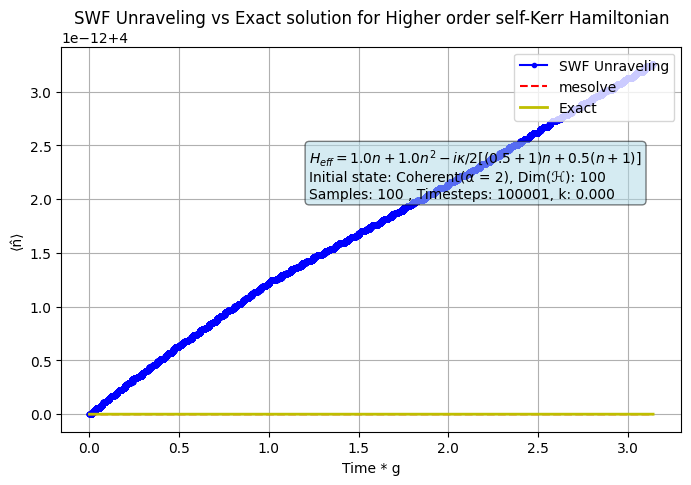

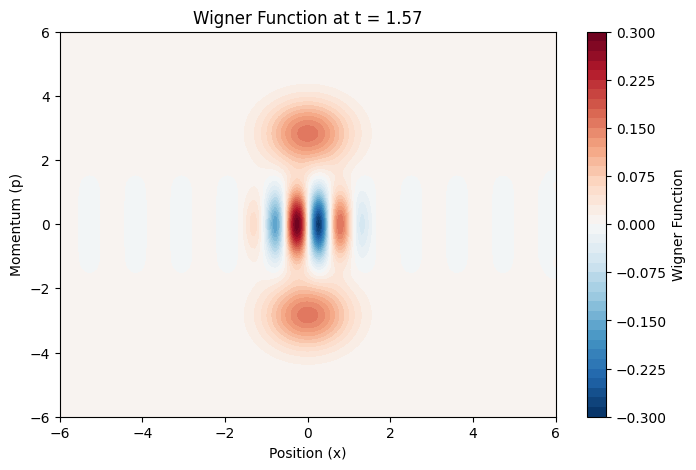

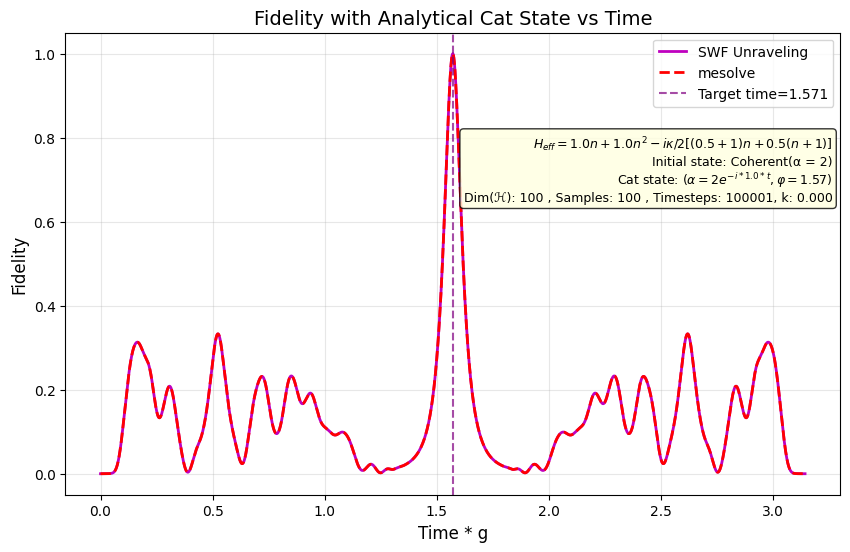

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
import time
import cmath 
from qutip import wigner

def format_time(seconds):
    """Convert seconds to hours, minutes, seconds format."""
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    secs = seconds % 60
    return f"{hours}h {minutes}m {secs:.1f}s"

def define_operators(N):
    """Define operators for dimension N."""
    a = qt.destroy(N)
    a_dag = qt.create(N)
    n = qt.num(N)
    x = qt.position(N)
    p = qt.momentum(N)
    return a, a_dag, n, x, p

# ==================== PARAMETERS ====================
N = int(input("Enter the Hilbert space dimension N: "))
a, a_dag, n, x, p = define_operators(N)

kappa = 0.0  # Damping rate
n_thermal = 0.5  # Thermal occupation number
Ls = [np.sqrt(kappa) * a] #single boson loss
#Ls = [cmath.sqrt(kappa * (n_thermal + 1)) * a,
#      cmath.sqrt(kappa * n_thermal) * a_dag]


omega, g, m = 1.0, 1.0, 2
H = omega * n + g * n**m
Heff = H - 1j/2 * sum(L.dag() * L for L in Ls)
str_H = f"${omega:.1f}*n + {g:.2f}*n^{m}$"
str_Heff = f"{str_H} $- iκ/2[({n_thermal}+1)n + {n_thermal}(n+1)]$"
str_Heff = f"{str_H} - iκ/2 n"

Amplitude = 2
psi0 = qt.coherent(N, Amplitude)
initial_state_str = f"Coherent(α = {Amplitude})"

# Time list
timestep = 1 + 10**5
final_time = (np.pi / (2 * g))*2.0
tlist = np.linspace(0, final_time, timestep)
dt_list = np.diff(tlist)

sample = 100
target_time = np.pi / (2 * g)
target_index = np.argmin(np.abs(tlist - target_time))

# Cat state
cat_state = (qt.coherent(N, Amplitude * np.exp(-1j * omega * target_time)) +
             np.exp(1j * np.pi / 2) * qt.coherent(N, -Amplitude * np.exp(-1j * omega * target_time)))
cat_state = cat_state / cat_state.norm()
cat_state_str = f"$(α={Amplitude}e^{{-i*{omega}*t}}, φ={np.pi/2:.2f})$"

# ==================== MANUAL MONTE CARLO ====================
mean_n = np.zeros(len(tlist), dtype=complex)
fidelity_cat = np.zeros(len(tlist))
state_at_target_time = qt.basis(N, 0) * 0  # Zero ket with correct dims

milestones = [0.001, 0.01, 0.1, 1, 5, 10, 20, 50, 75, 90, 100]
milestone_index = 0
start_time = time.time()

print("Starting Monte Carlo simulation...")

for count in range(sample):
    psi = psi0.copy()
    n_expect_list = [qt.expect(n, psi)]

    for i in range(1, len(tlist)):
        dt = dt_list[i - 1]
        dps = [np.real(dt * qt.expect(L.dag() * L, psi)) for L in Ls]
        dP = sum(dps)

        if dP < np.random.random():
            psi = ((-1.0j * Heff * dt).expm() * psi).unit()
        else:
            k = np.searchsorted(np.cumsum(dps) / dP, np.random.random())
            psi = (Ls[k] * psi).unit()

        n_expect_list.append(qt.expect(n, psi))
        fidelity_cat[i] += qt.fidelity(psi, cat_state)**2

        if i == target_index:
            state_at_target_time += psi

    mean_n += np.array(n_expect_list)

    progress = (count + 1) / sample * 100
    if milestone_index < len(milestones) and progress >= milestones[milestone_index]:
        elapsed = time.time() - start_time
        remaining = elapsed / (progress / 100) - elapsed
        print(f"{milestones[milestone_index]:.3f}% done, ETA: {format_time(remaining)}")
        milestone_index += 1

mean_n /= sample
fidelity_cat /= sample
state_at_target_time /= sample
state_at_target_time = state_at_target_time.unit()

print(f"Simulation completed in {format_time(time.time() - start_time)}.")
print(f"Final <n> = {np.real(mean_n[-1]):.6f}")

# Exact solution
n_exact = np.real(qt.expect(n, psi0)) * np.exp(-kappa * tlist)

# ==================== MESOLVE (OPTIONAL) ====================
mesolve_status = "failed"
result_mesolve = None
mean_n_mesolve = None
fidelity_cat_mesolve = []

 #Uncomment to enable mesolve:
try:
     result_mesolve = qt.mesolve(H, psi0, tlist, Ls, [n], options=qt.Options(store_states=True))
     mesolve_status = "success"
     mean_n_mesolve = result_mesolve.expect[0]
     fidelity_cat_mesolve = [qt.fidelity(rho, cat_state)**2 for rho in result_mesolve.states]
     print(f"mesolve completed.")
except Exception as e:
     print(f"mesolve failed: {e}")

# ==================== PLOTS ====================
# Plot 1: <n> vs time
plt.figure(figsize=(8, 5))
plt.plot(tlist, np.real(mean_n), '.-b', label="SWF Unraveling")
if mesolve_status == "success":
    plt.plot(tlist, mean_n_mesolve, '--r', label="mesolve")
plt.plot(tlist, n_exact, 'y-', linewidth=2, label="Exact")
plt.xlabel("Time * g")
plt.ylabel("⟨n̂⟩")
plt.title("SWF Unraveling vs Exact solution for Higher order self-Kerr Hamiltonian")
plt.legend(loc='upper right')
plt.grid(True)

param_text= (rf"$H_{{eff}} = {omega}n + {g}n^2 - i\kappa/2[({n_thermal}+1)n + {n_thermal}(n+1)]$" +
                f"\nInitial state: {initial_state_str}, Dim(ℋ): {N}"+
                f"\nSamples: {sample} , Timesteps: {timestep}, k: {kappa:.3f}" )
plt.text(0.4, 0.6, param_text, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='bottom', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.5))

# Plot 2: Wigner function
xvec = np.linspace(-6, 6, 200)
W_manual = wigner(state_at_target_time, xvec, xvec)

plt.figure(figsize=(8, 5))
plt.contourf(xvec, xvec, W_manual, levels=50, cmap='RdBu_r')
plt.colorbar(label='Wigner Function')
plt.xlabel('Position (x)')
plt.ylabel('Momentum (p)')
plt.title(f'Wigner Function at t = {target_time:.2f}')

# Plot 3: Fidelity
plt.figure(figsize=(10, 6))
plt.plot(tlist, fidelity_cat, '-m', linewidth=2, label='SWF Unraveling')
if mesolve_status == "success" and len(fidelity_cat_mesolve) == len(tlist):
    plt.plot(tlist, fidelity_cat_mesolve, '--r', linewidth=2, label='mesolve')
plt.axvline(x=target_time, color='purple', linestyle='--', alpha=0.7, label=f'Target time={target_time:.3f}')
plt.xlabel("Time * g", fontsize=12)
plt.ylabel("Fidelity", fontsize=12)
plt.title("Fidelity with Analytical Cat State vs Time", fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)


param_text_fid = (rf"$H_{{eff}} = {omega}n + {g}n^2 - i\kappa/2[({n_thermal}+1)n + {n_thermal}(n+1)]$" +
                f"\nInitial state: {initial_state_str}" +
                f"\nCat state: {cat_state_str}" +
                f"\nDim(ℋ): {N} , Samples: {sample} , Timesteps: {timestep}, k: {kappa:.3f}" )
plt.text(0.99, 0.78, param_text_fid, transform=plt.gca().transAxes, fontsize=9,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

plt.show()

In [ ]:
# --- STORE DATA INTO A CSV FILE ---

import pandas as pd
import os
import datetime

csv_file = "NL_simulation_results.csv"

# Helper function 
def safe_eval(var_name, default=None):
    """Safely evaluate a variable name, return default if not defined"""
    try:
        return eval(var_name)
    except NameError:
        return default

data_to_append = []

# --- UNRAVELING ---
try:
    entry = {
        "method": f"Unraveling",
        "order of nonlinearity m": safe_eval('m', 'unknown'),
        "nonlinear coupling g": safe_eval('g', 'unknown'),
        "dissipation rate κ": safe_eval('kappa.real', 'unknown'),
        "initial_state": safe_eval('initial_state_str', 'unknown'),
        "dimension": safe_eval('N', 'unknown'),
        "timesteps": safe_eval('timestep', 'unknown'),
        "samples": safe_eval('sample', 'unknown'),
        "total_simulation_time": safe_eval('total_time', 'unknown'),
        "relative error": safe_eval('rmse', 'unknown'),  
        "status": "success" #must be manually changed if the plot seems wrong
    }
    data_to_append.append(entry)
    print("✓ Unraveling saved")
except Exception as e:
    print(f"⚠ Unraveling error: {e}")

# --- MESOLVE ---
try:
    has_mesolve = safe_eval('mesolve_time') is not None
    
    if has_mesolve:
        entry = {
            "method": f"mesolve",
            "order of nonlinearity m": safe_eval('m', 'unknown'),
            "nonlinear coupling g": safe_eval('g', 'unknown'),
            "dissipation rate κ": safe_eval('kappa.real', 'unknown'),
            "initial_state": safe_eval('initial_state_str', 'unknown'),
            "dimension": safe_eval('N', 'unknown'),
            "timesteps": safe_eval('timestep', 'unknown'),
            "samples": 1,
            "total_simulation_time": safe_eval('mesolve_time', 'unknown'),
            "relative error": safe_eval('rmse_mesolve', 'unknown'),
            "status": mcsolve_status
        }
    else:
        entry = {
            "method": f"mesolve",
            "order of nonlinearity m": safe_eval('m', 'unknown'),
            "nonlinear coupling g": safe_eval('g', 'unknown'),
            "dissipation rate κ": safe_eval('kappa.real', 'unknown'),
            "initial_state": safe_eval('initial_state_str', 'unknown'),
            "dimension": safe_eval('N', 'unknown'),
            "timesteps": safe_eval('timestep', 'unknown'),
            "samples": 1,
            "total_simulation_time": None,
            "relative error": None,
            "status": mesolve_status
        }
    data_to_append.append(entry)
    print("✓ Mesolve saved")
except Exception as e:
    print(f"⚠ Mesolve error: {e}")

# --- MCSOLVE ---
try:
    has_mcsolve = safe_eval('mcsolve_time') is not None
    
    if has_mcsolve:
        entry = {
            "method": f"mcsolve",
            "order of nonlinearity m": safe_eval('m', 'unknown'),
            "nonlinear coupling g": safe_eval('g', 'unknown'),
            "dissipation rate κ": safe_eval('kappa.real', 'unknown'),
            "initial_state": safe_eval('initial_state_str', 'unknown'),
            "dimension": safe_eval('N', 'unknown'),
            "timesteps": safe_eval('timestep', 'unknown'),
            "samples": safe_eval('sample', 'unknown'),
            "total_simulation_time": safe_eval('mcsolve_time', 'unknown'),
            "relative error": safe_eval('rmse_mcsolve', 'unknown'),
            "status": mcsolve_status
        }
    else:
        entry = {
            "method": f"mcsolve",
            "order of nonlinearity m": safe_eval('m', 'unknown'),
            "nonlinear coupling g": safe_eval('g', 'unknown'),
            "dissipation rate κ": safe_eval('kappa.real', 'unknown'),
            "initial_state": safe_eval('initial_state_str', 'unknown'),
            "dimension": safe_eval('N', 'unknown'),
            "timesteps": safe_eval('timestep', 'unknown'),
            "samples": safe_eval('sample', 'unknown'),
            "total_simulation_time": None,
            "relative error": None,
            "status": mcsolve_status
        }
    data_to_append.append(entry)
    print("✓ MCSolve saved")
except Exception as e:
    print(f"⚠ MCSolve error: {e}")

# --- SAVE TO CSV ---
if data_to_append:
    df_new = pd.DataFrame(data_to_append)
    
    if os.path.exists(csv_file):
        try:
            df_existing = pd.read_csv(csv_file)
            df_combined = pd.concat([df_existing, df_new], ignore_index=True)
            df_combined.to_csv(csv_file, index=False)
            print(f"✓ Saved to {csv_file}")
        except:
            backup = f"results_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
            df_new.to_csv(backup, index=False)
            print(f"✓ Saved to {backup}")
    else:
        df_new.to_csv(csv_file, index=False)
        print(f"✓ Created {csv_file}")

# Display the current contents of the CSV
print(f"\nCurrent contents of {csv_file}:")
print(pd.read_csv(csv_file))        

In [ ]:
# ------------------- CREATE WIGNER ANIMATION -------------------

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# Load Wigner function data
data = np.load('wigner_data.npz')
wigner_functions = data['wigner_functions']
xvec = data['xvec']
Pvec = data['Pvec']
wigner_times = data['wigner_times']
wigner_neg_values = data['wigner_neg_values']
wigner_neg_fractions = data['wigner_neg_fractions']
str_H = str(data['str_H'])
initial_state_str = str(data['initial_state_str'])
N = int(data['N'])
g = float(data['g'])
m = int(data['m'])
kappa = complex(data['kappa'])
omega = float(data['omega'])
target_time = float(data['target_time'])
Amplitude = float(data['Amplitude'])
phase_cat = float(data['phase_cat'])

# Verify target_time is the last frame
print(f"First frame: t={wigner_times[0]:.6f}")
print(f"Last frame:  t={wigner_times[-1]:.6f}")
print(f"Target time: t={target_time:.6f}")
print(f"Match: {np.isclose(wigner_times[-1], target_time)}")

# Video parameters
fps = 24
dpi = 150
figsize = (10, 8)

# Create figure
fig, ax = plt.subplots(figsize=figsize)

# Find global min/max for consistent color scale
W_min = np.min([W.min() for W in wigner_functions])
W_max = np.max([W.max() for W in wigner_functions])

def update(frame):
    """Update function for animation"""
    ax.clear()
    
    W = wigner_functions[frame]
    t = wigner_times[frame]
    
    # Highlight if this is the target time frame
    is_target = np.isclose(t, target_time)
    title_color = 'red' if is_target else 'black'
    
    # Plot Wigner function
    im = ax.contourf(xvec, Pvec, W, levels=50, cmap='RdBu_r',
                     vmin=W_min, vmax=W_max)
    
    # Statistics
    W_neg_total = wigner_neg_values[frame]
    neg_fraction = wigner_neg_fractions[frame]
    
    # Title with time - mark target time explicitly
    if is_target:
        title_str = f'★ TARGET TIME ★\nt = {t:.6f} (EXACT)'
    else:
        title_str = f'Wigner Function Evolution\nt = {t:.3f} / target t = {target_time:.3f}'
    
    ax.set_title(title_str, fontsize=14, color=title_color, fontweight='bold' if is_target else 'normal')
    
    ax.set_xlabel('Position (x)', fontsize=12)
    ax.set_ylabel('Momentum (p)', fontsize=12)
    
    # Parameter box
    stats_text = (f"Parameters:\n"
                  f"Initial State: {initial_state_str}\n"
                  f"H: {str_H}\n"
                  f"N: {N}, g: {g}, m: {m}, κ: {kappa.real:.4f}\n"
                  f"Neg. Value: {W_neg_total:.4f}\n"
                  f"Neg. Fraction: {neg_fraction:.2f}%")
    
    ax.text(0.98, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))
    
    ax.set_xlim(xvec.min(), xvec.max())
    ax.set_ylim(Pvec.min(), Pvec.max())
    
    return [im]

# Create animation
anim = FuncAnimation(fig, update, frames=len(wigner_functions),
                     interval=1000//fps, blit=False)

# Save GIF
output_file = 'wigner_evolution_exact_target.gif'
print(f"\nSaving GIF to {output_file}...")

writer = PillowWriter(fps=fps)
anim.save(output_file, writer=writer, dpi=dpi)
print(f"GIF saved: {output_file}")
print(f"Duration: {len(wigner_functions)/fps:.1f}s, {len(wigner_functions)} frames at {fps} fps")
print(f"Final frame corresponds to t={wigner_times[-1]:.6f} = target_time={target_time:.6f}")

plt.close(fig)
print("Done!")